<a href="https://colab.research.google.com/github/Akulverma2/AIML-projects/blob/main/electricity_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
data = pd.read_csv("electricity_data.csv")

months = data["Month"]
units = data["UnitsConsumed"]
bill = data["BillAmount"]
hours = data["AppliancesHours"]
temp = data["Temperature"]
peak_units = data["PeakHoursUnits"]

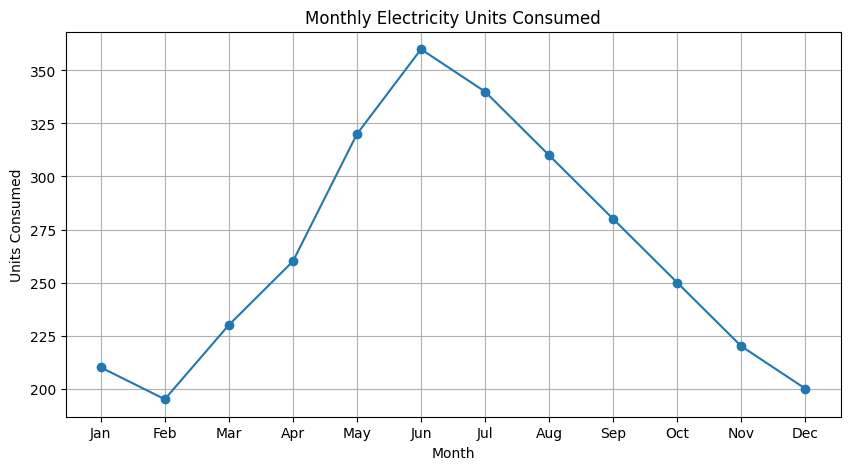

In [ ]:
# 1) Line Plot: Monthly Units Consumed
plt.figure(figsize=(10,5))
plt.plot(months, units, marker="o")
plt.title("Monthly Electricity Units Consumed")
plt.xlabel("Month")
plt.ylabel("Units Consumed")
plt.grid(True)
plt.show()

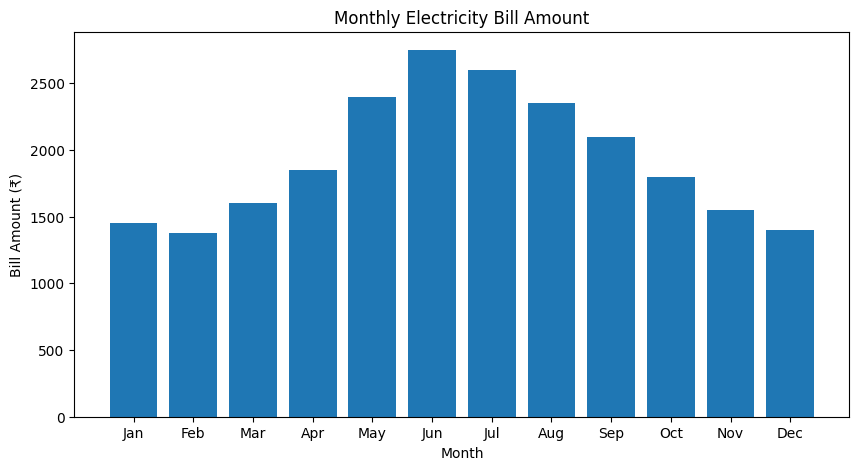

In [ ]:
# 2) Bar Chart: Monthly Bill Amount
plt.figure(figsize=(10,5))
plt.bar(months, bill)
plt.title("Monthly Electricity Bill Amount")
plt.xlabel("Month")
plt.ylabel("Bill Amount (₹)")
plt.show()

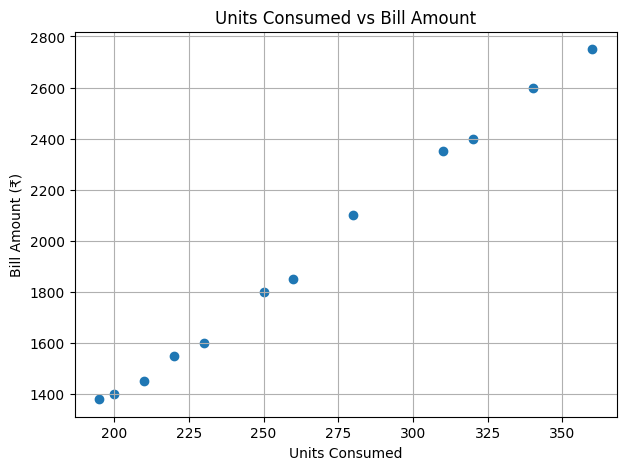

In [ ]:
# 3) Scatter Plot: Units vs Bill
plt.figure(figsize=(7,5))
plt.scatter(units, bill)
plt.title("Units Consumed vs Bill Amount")
plt.xlabel("Units Consumed")
plt.ylabel("Bill Amount (₹)")
plt.grid(True)
plt.show()

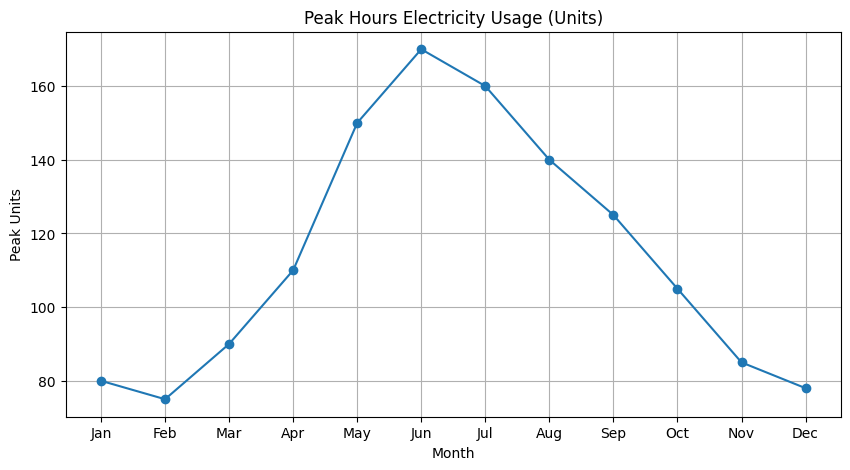

In [ ]:
# 4) Line Plot: Peak Hours Units
plt.figure(figsize=(10,5))
plt.plot(months, peak_units, marker="o")
plt.title("Peak Hours Electricity Usage (Units)")
plt.xlabel("Month")
plt.ylabel("Peak Units")
plt.grid(True)
plt.show()

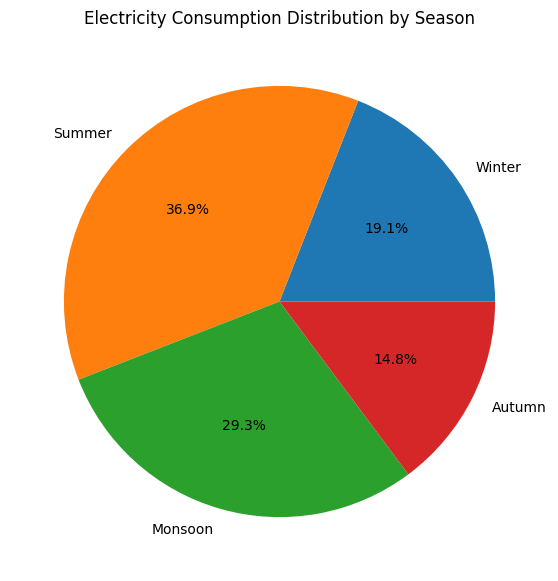

In [ ]:
# 5) Pie Chart: Total Units Distribution (Season-wise)
winter_units = data.loc[data["Month"].isin(["Dec", "Jan", "Feb"]), "UnitsConsumed"].sum()
summer_units = data.loc[data["Month"].isin(["Mar", "Apr", "May", "Jun"]), "UnitsConsumed"].sum()
monsoon_units = data.loc[data["Month"].isin(["Jul", "Aug", "Sep"]), "UnitsConsumed"].sum()
autumn_units = data.loc[data["Month"].isin(["Oct", "Nov"]), "UnitsConsumed"].sum()

season_units = [winter_units, summer_units, monsoon_units, autumn_units]
season_labels = ["Winter", "Summer", "Monsoon", "Autumn"]

plt.figure(figsize=(7,7))
plt.pie(season_units, labels=season_labels, autopct="%1.1f%%")
plt.title("Electricity Consumption Distribution by Season")
plt.show()

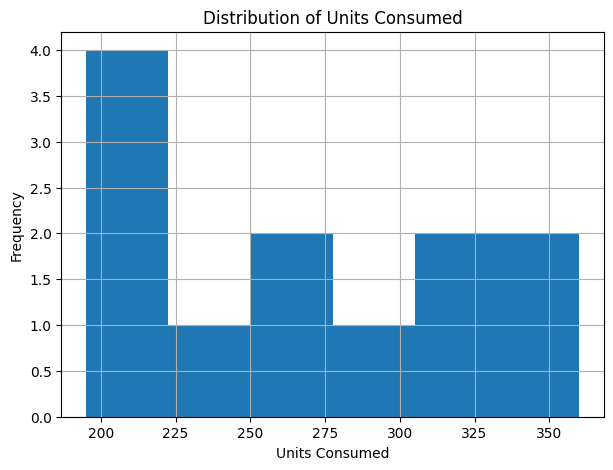

In [ ]:
# 6) Histogram: Units Distribution
plt.figure(figsize=(7,5))
plt.hist(units, bins=6)
plt.title("Distribution of Units Consumed")
plt.xlabel("Units Consumed")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [ ]:

# Features (X) and Target (y)
X = data[["UnitsConsumed"]]     # Input feature
y = data["BillAmount"]          # Output target

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n------ Linear Regression Results ------")
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)


------ Linear Regression Results ------
Mean Squared Error (MSE): 286.2658858539594
R2 Score: 0.9867877283452019


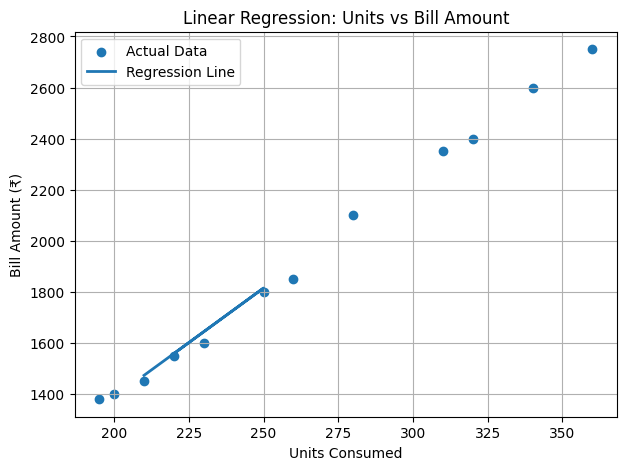

In [ ]:
# Plot Regression Line
plt.figure(figsize=(7,5))
plt.scatter(X, y, label="Actual Data")
plt.plot(X_test, y_pred, linewidth=2, label="Regression Line")
plt.title("Linear Regression: Units vs Bill Amount")
plt.xlabel("Units Consumed")
plt.ylabel("Bill Amount (₹)")
plt.grid(True)
plt.legend()
plt.show()